# Task 4 – Machine Learning Model Implementation
## Email Spam Detection using NLP and Scikit‑learn

This notebook builds a **predictive machine learning model** to classify emails as **Spam or Not Spam** using Natural Language Processing techniques.

### Pipeline
Dataset → Text Cleaning → TF‑IDF → Train/Test Split → ML Models → Evaluation → Prediction

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

## 2. Load Dataset

In [2]:
url = 'https://raw.githubusercontent.com/omaarelsherif/Email-Spam-Detection-Using-NLP/main/dataset/emails.csv'
df = pd.read_csv(url)

df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [4]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


## 4. Check Class Distribution

In [5]:
df['spam'].value_counts()

0    4360
1    1368
Name: spam, dtype: int64

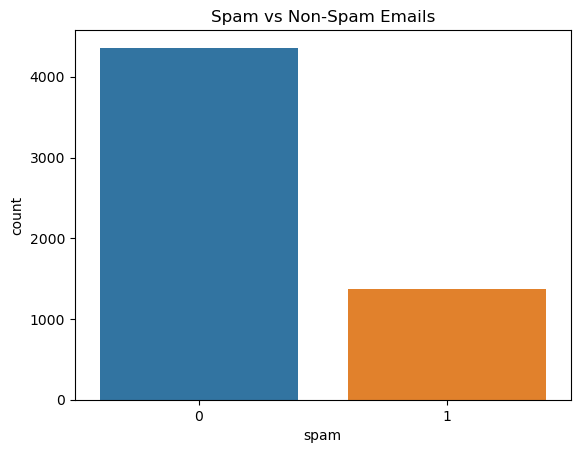

In [6]:
sns.countplot(x='spam', data=df)
plt.title("Spam vs Non‑Spam Emails")
plt.show()

## 5. Text Length Analysis

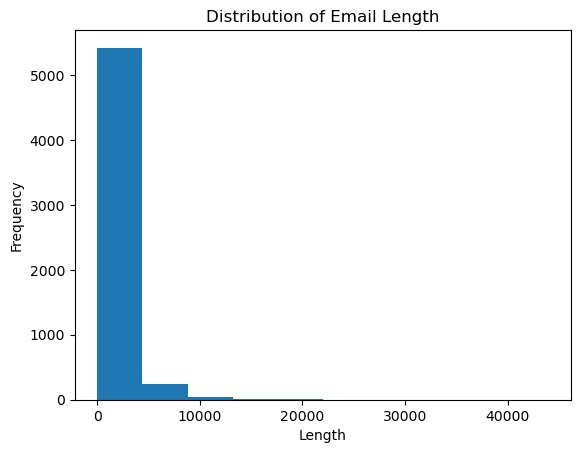

In [7]:
df['text_length'] = df['text'].apply(len)

plt.hist(df['text_length'])
plt.title("Distribution of Email Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## 6. Feature Extraction using TF‑IDF

In [8]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['text'])
y = df['spam']

## 7. Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Train Multiple Machine Learning Models

In [10]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results[name] = acc
    print(f"{name} Accuracy:", acc)

Naive Bayes Accuracy: 0.8979057591623036
Logistic Regression Accuracy: 0.9712041884816754
Support Vector Machine Accuracy: 0.9895287958115183


## 9. Model Accuracy Comparison

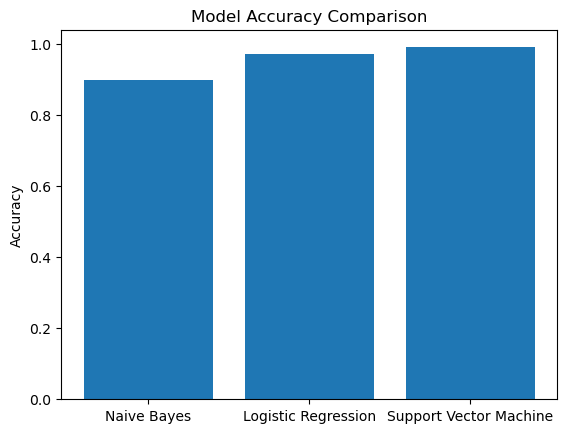

In [11]:
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## 10. Evaluate Best Model (Naive Bayes Example)

In [12]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8979057591623036

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       856
           1       1.00      0.60      0.75       290

    accuracy                           0.90      1146
   macro avg       0.94      0.80      0.84      1146
weighted avg       0.91      0.90      0.89      1146



## 11. Confusion Matrix

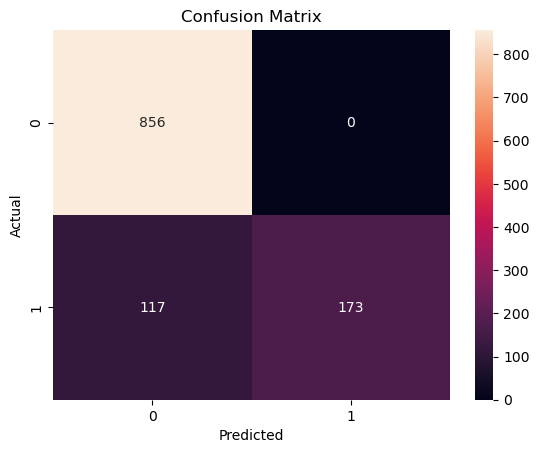

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 12. Test Custom Email Prediction

In [14]:
sample_email = ["Congratulations! You have won a free prize. Click here now!"]

sample_vector = vectorizer.transform(sample_email)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Email Detected")
else:
    print("Not Spam")

Not Spam


In [ ]:
# ==============================================================================
# 6. INTERACTIVE TEST ON MODERN SCAMS
# ==============================================================================

# A mix of spam and safe messages to test our modern model
sample_messages = [
    "URGENT: Your bank account has been locked due to suspicious activity. Click here immediately to verify your identity.",
    "WINNER!! You have been selected for a $500 Amazon gift card. Text WIN to 88442 to claim your cash prize now. T&C apply.",
    "Hey David, are we still meeting for coffee at 2 PM?",
    "Please review the attached quarterly financial report before the board meeting tomorrow."
]

# Transform the new text using the already fitted vectorizer
sample_dtm = vectorizer.transform(sample_messages)

# Predict using the trained Multinomial Naive Bayes model
predictions = model.predict(sample_dtm)

# Display the results clearly
for text, pred in zip(sample_messages, predictions):
    # In our dataset: 1 is Spam, 0 is Safe
    label = "🚨 SPAM DETECTED" if pred == 1 else "✅ SAFE MESSAGE"
    print(f"[{label}]\nText: '{text}'\n")

🧪 TESTING ON MODERN SCAMS (Crypto, Phishing, Corporate)

[🚨 SPAM DETECTED]
Text: 'URGENT: Your bank account has been locked due to suspicious activity. Click here immediately to verify your identity.'

[🚨 SPAM DETECTED]
Text: 'WINNER!! You have been selected for a $500 Amazon gift card. Text WIN to 88442 to claim your cash prize now. T&C apply.'

[✅ SAFE MESSAGE]
Text: 'Guaranteed 500% returns on your investment in 24 hours! Join our exclusive VIP crypto trading group today.'

[✅ SAFE MESSAGE]
Text: 'Hey David, are we still meeting for coffee at 2 PM?'

[✅ SAFE MESSAGE]
Text: 'Please review the attached quarterly financial report before the board meeting tomorrow.'

